In [1]:
import numpy as np
import matplotlib.pyplot as plt
from astropy import units as u
from astropy.coordinates import SkyCoord
from astropy.table import Table
from astropy.cosmology import LambdaCDM
import redback
from redback.simulate_transients import SimulateGenericTransient
import pandas as pd
from bilby.core.prior import Uniform
from bilby.core.prior.dict import PriorDict
from scipy import integrate
from scipy.interpolate import interp1d
from spherical_geometry.polygon import SphericalPolygon
import os

## Cosmology
cosmo = LambdaCDM(H0=70. *u.km / u.s / u.Mpc, Om0=0.3, Ode0=0.70)

## Differential Comoving Volume
def diff_cm_volume(z):
    dvol = cosmo.differential_comoving_volume(z)
    return dvol.value ## In Mpc^3


## Rate Functions

def rate_CCSN(z):
    R = (1.365e-4)*((1+z)**5)/(1+((1+z)/1.5)**6.1)
    return R

def rate_SNII(z):       ## Assuming 70% of CCSN are SN II
    R = rate_CCSN(z)*0.70
    return R

def rate_SNIc(z):       ## Assumining remaining 30% of CCSN are SNIbc
    R = rate_CCSN(z)*0.15
    return R

def rate_SNIb(z):
    R = rate_CCSN(z)*0.15
    return R

def rate_SNIax(z):
    R = (6e-6)*((1+z)**2.7)/(1+((1+z)/2.9)**5.6)
    return R

def rate_SNIa(z):
    r_smallz = (2.5e-5)*(1+z)**1.5
    r_bigz = (9.7e-5)*(1+z)**(-0.5)
    R = np.where(z<=1, r_smallz,
        np.where(z>1, r_bigz, 0))
    return R

def rate_TDE(z):
    R = (1e-6)*10**(-0.009*(z**3) + 0.121*(z**2) - 0.850*z)
    return R

def rate_GRB_L(z):
    z1 = 3.11
    R_0 = 1.25e-9
    r_smallz = (1+z)**2.07
    r_bigz = ((1+z1)**(3.43))*(1+z)**(-1.36)
    R = np.where(z<z1, R_0*r_smallz,
        np.where(z>=z1, R_0*r_bigz, 0))
    return R

def rate_GRB_S(z):
    R = 1e-7*(z**0)
    return R


## Transient Number Functions, integrands

def N_CCSN(z):
    N = rate_CCSN(z)*diff_cm_volume(z)
    return N

def N_SNII(z):
    N = rate_SNII(z)*diff_cm_volume(z)
    return N

def N_SNIc(z):
    N = rate_SNIc(z)*diff_cm_volume(z)
    return N

def N_SNIb(z):
    N = rate_SNIb(z)*diff_cm_volume(z)
    return N

def N_TDE(z):
    N = rate_TDE(z)*diff_cm_volume(z)
    return N

def N_SNIa(z):
    N = rate_SNIa(z)*diff_cm_volume(z)
    return N

def N_SNIax(z):
    N = rate_SNIax(z)*diff_cm_volume(z)
    return N

def N_GRB_L(z):
    N = rate_GRB_L(z)*diff_cm_volume(z)
    return N

def N_GRB_S(z):
    N = rate_GRB_S(z)*diff_cm_volume(z)
    return N



TDE_params = {'Model': 'tde_fallback', 'Rate Function': rate_TDE, 'Number Function': N_TDE, 'deltaT': 56.0/365.2425}
SNII_params = {'Model': 'typeII_surrogate_sarin25', 'Rate Function': rate_SNII, 'Number Function': N_SNII, 'deltaT': 55.0/365.2425}
SNIa_params = {'Model': 'salt2', 'Rate Function': rate_SNIa, 'Number Function': N_SNIa, 'deltaT': 25.0/365.2425}
SNIb_params = {'Model': 'arnett', 'Rate Function': rate_SNIb, 'Number Function': N_SNIb, 'deltaT': 55.0/365.2425}
SNIc_params = {'Model': 'type_1c', 'Rate Function': rate_SNIc, 'Number Function': N_SNIc, 'deltaT': 55.0/365.2425}
GRB_L_params = {'Model': 'gaussian_redback', 'Rate Function': rate_GRB_S, 'Number Function': N_GRB_S, 'deltaT': 1.0/365.2425}
GRB_S_params = {'Model': 'gaussian_redback', 'Rate Function': rate_GRB_L, 'Number Function': N_GRB_L, 'deltaT': 20.0/365.2425}


transients = {'TDE': TDE_params,
              'SNII': SNII_params,
              'SNIa': SNIa_params,
              'SNIb': SNIb_params,
              'SNIc': SNIc_params,
              'sGRB': GRB_L_params,
              'lGRB': GRB_S_params}


transients_GroupA = {'TDE': TDE_params,
                     'SNII': SNII_params,
                     'SNIb': SNIb_params,
                     'SNIc': SNIc_params,
                     'SNIa': SNIa_params}

transients_GroupB = {'sGRB': GRB_S_params,
                     'lGRB': GRB_L_params}



# transients_GroupC = 



###
### Ok so I need to group all 8 transient types into the groups that share similar simulation set-ups:
### TDEs, CCSN all can produce MULTIBAND lightcurves with MAGNITUDE outputs (4)
### SNIa can only produce SINGLE BAND lightcurves with MAGNITUDE outputs (1)
### GRBs can produce MULTIBAND lightcurves with FLUX DENSITY outputs (2)
### SNIax is a whole different beast (1)


No module named 'lalsimulation'
lalsimulation is not installed. Some EOS based models will not work. Please use bilby eos or pass your own EOS generation class to the model
14:38 bilby INFO    : Running bilby version: 2.6.0
14:38 redback INFO    : Running redback version: 1.12.1


In [7]:
for transient in transients:
    print(transient)
    print(list(transients.keys()))

TDE
['TDE', 'SNII', 'SNIa', 'SNIb', 'SNIc', 'sGRB', 'lGRB']
SNII
['TDE', 'SNII', 'SNIa', 'SNIb', 'SNIc', 'sGRB', 'lGRB']
SNIa
['TDE', 'SNII', 'SNIa', 'SNIb', 'SNIc', 'sGRB', 'lGRB']
SNIb
['TDE', 'SNII', 'SNIa', 'SNIb', 'SNIc', 'sGRB', 'lGRB']
SNIc
['TDE', 'SNII', 'SNIa', 'SNIb', 'SNIc', 'sGRB', 'lGRB']
sGRB
['TDE', 'SNII', 'SNIa', 'SNIb', 'SNIc', 'sGRB', 'lGRB']
lGRB
['TDE', 'SNII', 'SNIa', 'SNIb', 'SNIc', 'sGRB', 'lGRB']


In [2]:
# ---------------------------------------
# Model Priors
# ---------------------------------------

# Type Ib Priors
TypeIb_priors = PriorDict({'mej': Uniform(minimum=1, maximum=10, name='mej'),
                            'Ek': Uniform(minimum=1, maximum=10, name='Ek'),
                            'f_nickel': Uniform(minimum=0.01, maximum=0.15, name='f_nickel')})

def update_parameters(params, trans_type):
    if trans_type == 'SNIb':            ## For SNIb
        model = transients[trans_type]['Model']
        params = redback.priors.get_priors(model=model).sample()
        
        mej = TypeIb_priors['mej'].sample()
        f_nickel = TypeIb_priors['f_nickel'].sample()
        Ek = TypeIb_priors['Ek'].sample()
        const = np.sqrt(2./1.989e33)*1e-5
        vej = const*np.sqrt(Ek*1e51/mej)
        params['mej'] = mej
        params['f_nickel'] = f_nickel
        params['vej'] = vej
        
    else:               ## For SNIa, SNII, SNIc, and TDE
        model = transients[trans_type]['Model']
        params = redback.priors.get_priors(model=model).sample()
    return params






In [3]:
class TransientContaminants:
    def __init__(self, coordinates, z_max=2, z_min=0):
        """
        Coordinates must be in the form of astropy SkyCoord object.


        """
        self.coordinates = coordinates
        self.z_max = z_max
        self.z_min = z_min

    ## Return the sky localization area bound by the input coordinates
    def compute_sky_area(self, unit=u.sr):
        """
        Computes the total area on the sky bound by the input coordinates. 
        unit: astropy unit for surface area of a sphere (default is steradian)
        """
        coords = self.coordinates

        coords_cartesian = coords.cartesian
        verts = np.column_stack((coords_cartesian.x.value, coords_cartesian.y.value, coords_cartesian.z.value))
        sky_polygon = SphericalPolygon(verts)



        sky_area = sky_polygon.area() * u.steradian
        output = sky_area.to(unit)
        return output
    
    ## Return the projected integrated localization volume 
    def compute_projected_volume(self):
        """
        Computes the total localization volume projected along the line of sight.
        """
        area = self.compute_sky_area().value
        z_min = self.z_min
        z_max = self.z_max
        integrand = integrate.quad(diff_cm_volume, z_min, z_max)[0]
        vol = (area/(4*np.pi)) * integrand * u.Mpc**3
        return vol 
    
    ## Return the total number of expected transient contaminants in the localization volume
    def compute_transients(self, trans_type=list(transients.keys())):
        """
        Computes the total number of expected transients in the localization volume over a ten year period.
        trans_type: list of types of transients you wish to compute the number of. Default is full set of transients with rates: SNIa, SNIb, SNIc, SNII, SNIax, sGRB, lGRB, TDE
        """
        N_tot = 0
        z_min = self.z_min
        z_max = self.z_max
        try:
            for transient in trans_type:
                area = self.compute_sky_area().value
                N_trans = transients[transient]['Number Function']
                integrand = integrate.quad(N_trans, z_min, z_max)[0]
                N = (area/(4*np.pi))*integrand*10               # Multiply by 10 instead of deltaT for a 10 year period.
                N_tot += N
            return N_tot
        except KeyError:
            print('ERROR: Transient type not recognized. Must be set of the following:\nSNII, SNIa, SNIb, SNIc, TDE, sGRB, lGRB, SNIax')
    

    # Return FITS files of lightcurves for each expected transient contiminant
    def generate_transients(self):              ### ADD TRY STATEMENTS TO AVOID CRASHES FOR ALL MODELS, ESPECIALLY TDES
        """
        Generates lightcurves for each transient expected in the localization volume.
        """
        area = self.compute_sky_area().value
        z_min = self.z_min
        z_max = self.z_max
        z_list = np.linspace(z_min, z_max, 100)

        os.makedirs('TransientContaminantsOutput', exist_ok=True)

        ## TDEs and CCSN, output is multiband lightcurves in units of AB Magnitude
        for transient in transients_GroupA:
            N_trans = transients_GroupA[transient]['Number Function']
            integrand = integrate.quad(N_trans, z_min, z_max)[0]
            N_type = (area/(4*np.pi))*integrand*10 # number per year * 10 years of LISA

            t_lisa = np.linspace(0.2, 3650, 10000)  # Time of LISA mission

            times = np.linspace(0.2,3650,10000)
            bands = 'lssti'

            n_datapoints = 10000
            kwargs = {'output_format': 'magnitude', 'bands': bands}
            model = transients_GroupA[transient]['Model']


            z_pdf = N_trans(z_list)/np.trapezoid(N_trans(z_list), z_list)
            delta_z = z_list[1] - z_list[0]
            z_cdf = np.cumsum(z_pdf) * delta_z
            z_interp = interp1d(z_cdf, z_list, kind='linear')

            print(f'Producing {int(N_type)} {transient} lightcurves.')
            for i in range(int(N_type)):
                try:
                    parameters = {}
                    parameters = update_parameters(parameters, transient)
                    parameters['redshift'] = z_interp(np.random.rand())
                    sim_obs = SimulateGenericTransient(model=model, parameters=parameters, times=times, data_points=n_datapoints,
                                                        model_kwargs=kwargs, noise_term=0.02)
                    sim_data = sim_obs.data

                    # ----------------------
                    # Change sim_data to master dataframe (Puts the lightcurve at a random point in LISA mission frame)
                    # ----------------------
                    randindex = np.random.randint(0,10000)
                    t0 = t_lisa[randindex]

                    sim_data['time'] = sim_data['time'] + t0

                    sim_data.set_index('time')
                    sim_data = sim_data[sim_data['time'] <= 3650]

                    master_data = pd.DataFrame(columns=['time', 'band', 'true_output', 'output', 'output_error'])
                    master_data['time'] = t_lisa
                    master_data['output'] = float('inf')

                    master_data = master_data.set_index('time')
                    sim_data = sim_data.set_index('time')

                    master_data.update(sim_data)
                    master_data = master_data.reset_index()

                    # saving lightcurve to FITS file
                    obj_id = f'{i:05d}'
                    filename = f'{transient}_lightcurve_{obj_id}.fits'
                    filepath = f'TransientContaminantsOutput/{filename}'
                    astro_table = Table.from_pandas(master_data)
                    astro_table.meta = {'Model': model,
                                        'ID': obj_id}
                    astro_table.meta.update(parameters)
                    astro_table.write(filepath, overwrite=True)

                except Exception:
                    print(f'Error producing {transient} lightcurve.')
        
        ## For short and long GRBs, outputs multiband lightcurves in flux density??
        for transient in transients_GroupB:
            N_trans = transients_GroupB[transient]['Number Function']
            integrand = integrate.quad(N_trans, z_min, z_max)[0]
            N_type = (area/(4*np.pi))*integrand*10

            times = np.linspace(0.2,3650,10000)        ################## TIMES??
            bands = 'lssti'
            freqs = redback.utils.bands_to_frequency(bands)

            n_datapoints = 100
            kwargs = {'output_format':'flux_density', 'frequency': freqs}
            model = transients_GroupB[transient]['Model']       ########### Model differences between short and long GRBs?

            z_pdf = N_trans(z_list)/np.trapezoid(N_trans(z_list), z_list)
            delta_z = z_list[1] - z_list[0]
            z_cdf = np.cumsum(z_pdf) * delta_z
            z_interp = interp1d(z_cdf, z_list, kind='linear')
            print(f'Producing {int(N_type)} {transient} lightcurves.')
            for i in range(int(N_type)):
                ## SET UP PARAMETERS FOR S AND L GRBs
                ##
                try:
                    parameters = redback.priors.get_priors(model=model).sample()
                    parameters['redshift'] = z_interp(np.random.rand())
                    ## SET UP PARAMETERS
                    sim_obs = SimulateGenericTransient(model=model, parameters=parameters,times=times, data_points=n_datapoints,
                                                        model_kwargs=kwargs, noise_term=0.02)
                    sim_data = sim_obs.data

                    ## First, convert flux density ('output') to magnitude
                    ## Convert output errors to magnitude errors
                    ## Add start time and repeat process from above (TDEs and SNe)

                    # saving lightcurve to FITS file
                    obj_id = f'{i:05d}'
                    filename = f'{transient}_lightcurve_{obj_id}.fits'
                    filepath = f'TransientContaminantsOutput/{filename}'
                    astro_table = Table.from_pandas(sim_data)
                    astro_table.meta = {'Model': model,
                                        'ID': obj_id}
                    astro_table.meta.update(parameters)
                    astro_table.write(filepath, overwrite=True)
                except Exception:
                    print(f'{Exception} producing {transient} lightcurve.')

        return

In [ ]:

def mag_from_flux(flux):
    return (-2.5)*np.log10(flux/3631)


In [ ]:
alcyone = "03h47m29.07s +24d06m18.5s"
maia = "03h45m49.6066s +24d22m03.886s"
electra = "03h44m52.53688s +24d06m48.0112s"
merope = "03h46m19.6s +23d56m54s"
pleiades = [alcyone, maia, electra, merope]

aldebaran = '04h35m55s +16d30m33s'
gamma_tauri = '04h21m17.06s +15d41m29.8s'
epsilon_tauri = '04h28m37s +19d10m49s'
delta_tauri = '04h22m56.1s +17d32m33s'
hyades = [aldebaran, gamma_tauri, delta_tauri,epsilon_tauri]

mintaka = '05h32m00.4s -00d17m57s'
alnitak = '05h40m45.5s -01d56m34s'
betelgeuse = '05h55m10s +07d24m25s'
bellatrix = '05h25m07.9s +06d20m59s'
orion = [alnitak, mintaka, bellatrix, betelgeuse]

sirius = '06h45m09s -16d42m58s'
procyon = '07h39m18s 05d13m30s'

winter_triangle = [betelgeuse, sirius, procyon]


The total sky area is: 6.312600748118988 deg2
The projected localization volume is: 7089025.300880496 Mpc3
The total number of transients is: 44346.98751626643
The number of GRBs is: 7.613554481900863


The total sky area is: 38.971733871874896 deg2
The projected localization volume is: 43765100.702626444 Mpc3
The total number of transients is: 273782.40197089635
The estimated lightcurve generation time is: 547.5648039417927 minutes.


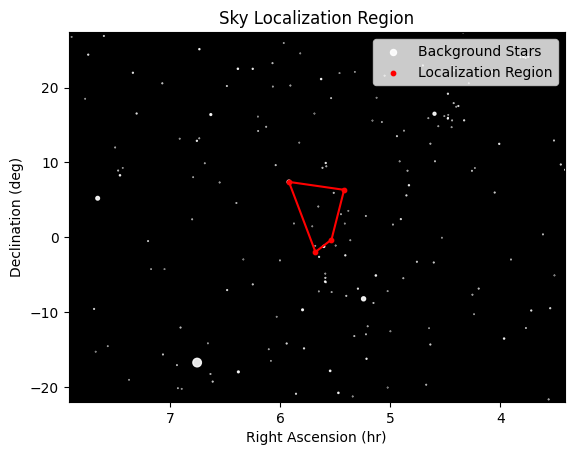

In [122]:
coords = SkyCoord(orion, frame='icrs')

trans = TransientContaminants(coords)
print(f'The total sky area is: {trans.compute_sky_area(unit=u.deg**2)}')
print(f'The projected localization volume is: {trans.compute_projected_volume()}')
print(f'The total number of transients is: {trans.compute_transients()}\nThe estimated lightcurve generation time is: {trans.compute_transients()/500} minutes.')
# print(f'The number of GRBs is: {trans.compute_transients(trans_type=['sGRB', 'lGRB'])}')
# print(trans.generate_transients())

## 1 min per 500 lightcurves

star_df = pd.read_csv('hygdata_v42.csv.gz')
star_df = star_df[['ra', 'dec', 'proper', 'mag']]
star_df = star_df[star_df['mag']<5]
star_df = star_df[star_df['mag'] > -25]

stars = SkyCoord(ra=star_df['ra'].values * u.hour, dec=star_df['dec'].values * u.degree, frame='icrs')

area_ra = list(coords.ra.hour)
area_dec = list(coords.dec.deg)

ra_closed = np.append(area_ra, area_ra[0])
dec_closed = np.append(area_dec, area_dec[0])

size = 10 * 10**(-0.4 * star_df['mag'])

plt.scatter(star_df['ra'], star_df['dec'], c='white', s=size, label='Background Stars', alpha=0.9)
plt.scatter(coords.ra.hour, coords.dec.deg, c='red', s=10, label='Localization Region')
plt.plot(ra_closed, dec_closed, c='red')

ra_min = np.min(coords.ra.hour) - 2
ra_max = np.max(coords.ra.hour) + 2

dec_min = np.min(coords.dec.deg) - 20
dec_max = np.max(coords.dec.deg) + 20
plt.xlim(ra_max, ra_min)
plt.ylim(dec_min, dec_max)

ax = plt.gca()
ax.set_facecolor('black')

ax.set_xlabel('Right Ascension (hr)')
ax.set_ylabel('Declination (deg)')
plt.title('Sky Localization Region')
plt.legend(loc='upper right')
plt.show()